In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

%matplotlib inline

# Base path
BASE_PATH = '/Users/zabir/Downloads/semi-AD/semi-AD'

# Subset paths
SUBSETS = {
    'ball_side': f'{BASE_PATH}/IC_substrate/ball_side',
    'chip_side': f'{BASE_PATH}/IC_substrate/chip_side',
    'wafer':     f'{BASE_PATH}/Wafer/patterned'
}

print("Paths configured.")
print("Subsets:", list(SUBSETS.keys()))

Paths configured.
Subsets: ['ball_side', 'chip_side', 'wafer']


In [2]:
def count_images(path):
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

print("=" * 60)
print(f"{'Subset':<12} {'Set':<10} {'Split':<12} {'Type':<10} {'Count':>6}")
print("=" * 60)

for name, base in SUBSETS.items():
    for set_type in ['pair_set', 'single_set']:
        for split in ['train', 'test']:
            for category in ['good', 'defect']:
                path = f'{base}/{set_type}/{split}/{category}'
                count = count_images(path)
                if count > 0:
                    print(f"{name:<12} {set_type:<10} {split:<12} {category:<10} {count:>6}")

print("=" * 60)

Subset       Set        Split        Type        Count
ball_side    pair_set   train        good         2791
ball_side    pair_set   test         good         2350
ball_side    pair_set   test         defect        321
ball_side    single_set train        good         5582
ball_side    single_set test         good         5018
ball_side    single_set test         defect        324
chip_side    pair_set   train        good         3435
chip_side    pair_set   test         good         2607
chip_side    pair_set   test         defect        143
chip_side    single_set train        good         6870
chip_side    single_set test         good         5353
chip_side    single_set test         defect        147
wafer        pair_set   train        good         3350
wafer        pair_set   test         good         2267
wafer        pair_set   test         defect        293
wafer        single_set train        good         6700
wafer        single_set test         good         4784
wafer     

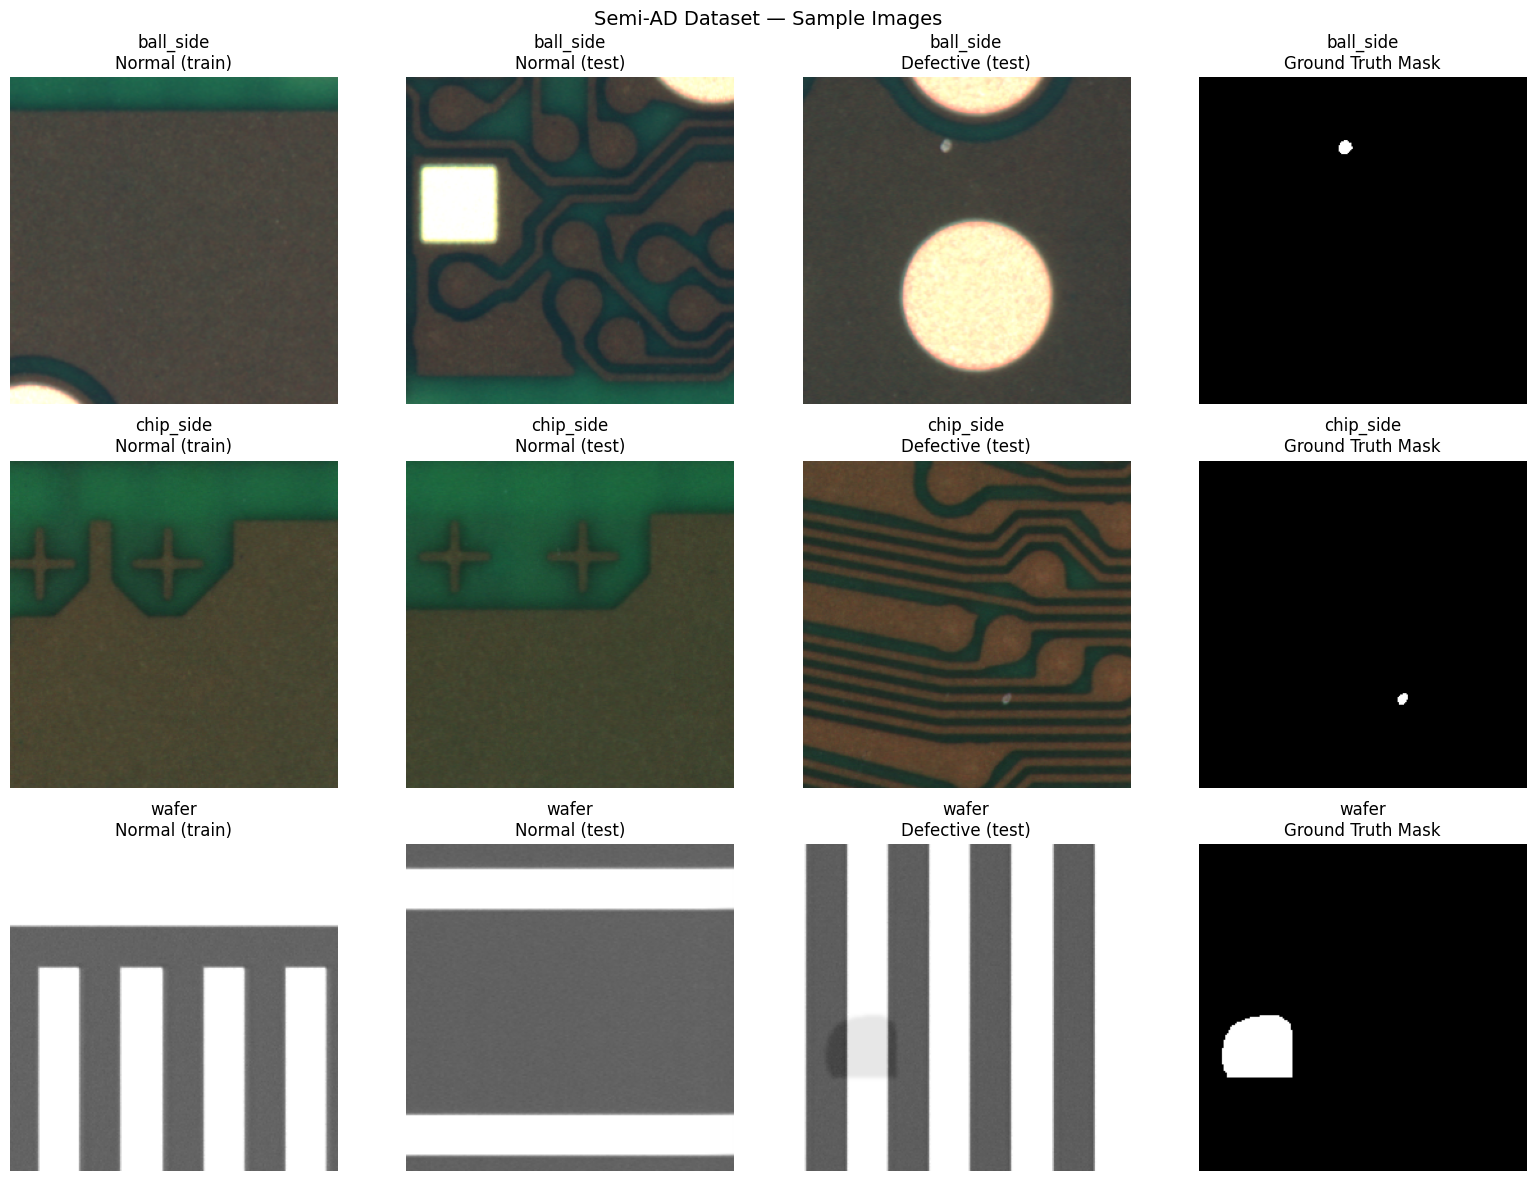

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
subsets_list = ['ball_side', 'chip_side', 'wafer']

for row, name in enumerate(subsets_list):
    base = SUBSETS[name]
    
    # Normal train image
    train_path = f'{base}/single_set/train/good'
    train_imgs = os.listdir(train_path)
    img = Image.open(f'{train_path}/{train_imgs[0]}')
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name}\nNormal (train)')
    axes[row, 0].axis('off')
    
    # Normal test image
    test_good_path = f'{base}/single_set/test/good'
    test_good_imgs = os.listdir(test_good_path)
    img = Image.open(f'{test_good_path}/{test_good_imgs[0]}')
    axes[row, 1].imshow(img, cmap='gray')
    axes[row, 1].set_title(f'{name}\nNormal (test)')
    axes[row, 1].axis('off')
    
    # Defective test image
    test_defect_path = f'{base}/single_set/test/defect'
    test_defect_imgs = os.listdir(test_defect_path)
    img = Image.open(f'{test_defect_path}/{test_defect_imgs[0]}')
    axes[row, 2].imshow(img, cmap='gray')
    axes[row, 2].set_title(f'{name}\nDefective (test)')
    axes[row, 2].axis('off')
    
    # Ground truth mask
    gt_path = f'{base}/single_set/ground_truth/defect'
    gt_imgs = os.listdir(gt_path)
    img = Image.open(f'{gt_path}/{gt_imgs[0]}')
    axes[row, 3].imshow(img, cmap='gray')
    axes[row, 3].set_title(f'{name}\nGround Truth Mask')
    axes[row, 3].axis('off')

plt.suptitle('Semi-AD Dataset — Sample Images', fontsize=14)
plt.tight_layout()
reports_path = os.path.expanduser('~/Documents/SemiAD/reports')
os.makedirs(reports_path, exist_ok=True)

plt.savefig(f'{reports_path}/eda_samples.png', bbox_inches='tight', dpi=150)
plt.show()

In [4]:
def get_image_size(path):
    imgs = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    if not imgs:
        return None
    img = Image.open(f'{path}/{imgs[0]}')
    return img.size, img.mode

print("=" * 60)
print(f"{'Subset':<12} {'Set':<12} {'Split':<8} {'Type':<10} {'Size':<15} {'Mode'}")
print("=" * 60)

for name, base in SUBSETS.items():
    for set_type in ['single_set']:
        for split, category in [('train', 'good'), ('test', 'good'), ('test', 'defect')]:
            path = f'{base}/{set_type}/{split}/{category}'
            result = get_image_size(path)
            if result:
                size, mode = result
                print(f"{name:<12} {set_type:<12} {split:<8} {category:<10} {str(size):<15} {mode}")

print("=" * 60)

Subset       Set          Split    Type       Size            Mode
ball_side    single_set   train    good       (256, 256)      RGB
ball_side    single_set   test     good       (256, 256)      RGB
ball_side    single_set   test     defect     (256, 256)      RGB
chip_side    single_set   train    good       (256, 256)      RGB
chip_side    single_set   test     good       (256, 256)      RGB
chip_side    single_set   test     defect     (256, 256)      RGB
wafer        single_set   train    good       (200, 200)      RGB
wafer        single_set   test     good       (200, 200)      RGB
wafer        single_set   test     defect     (200, 200)      RGB


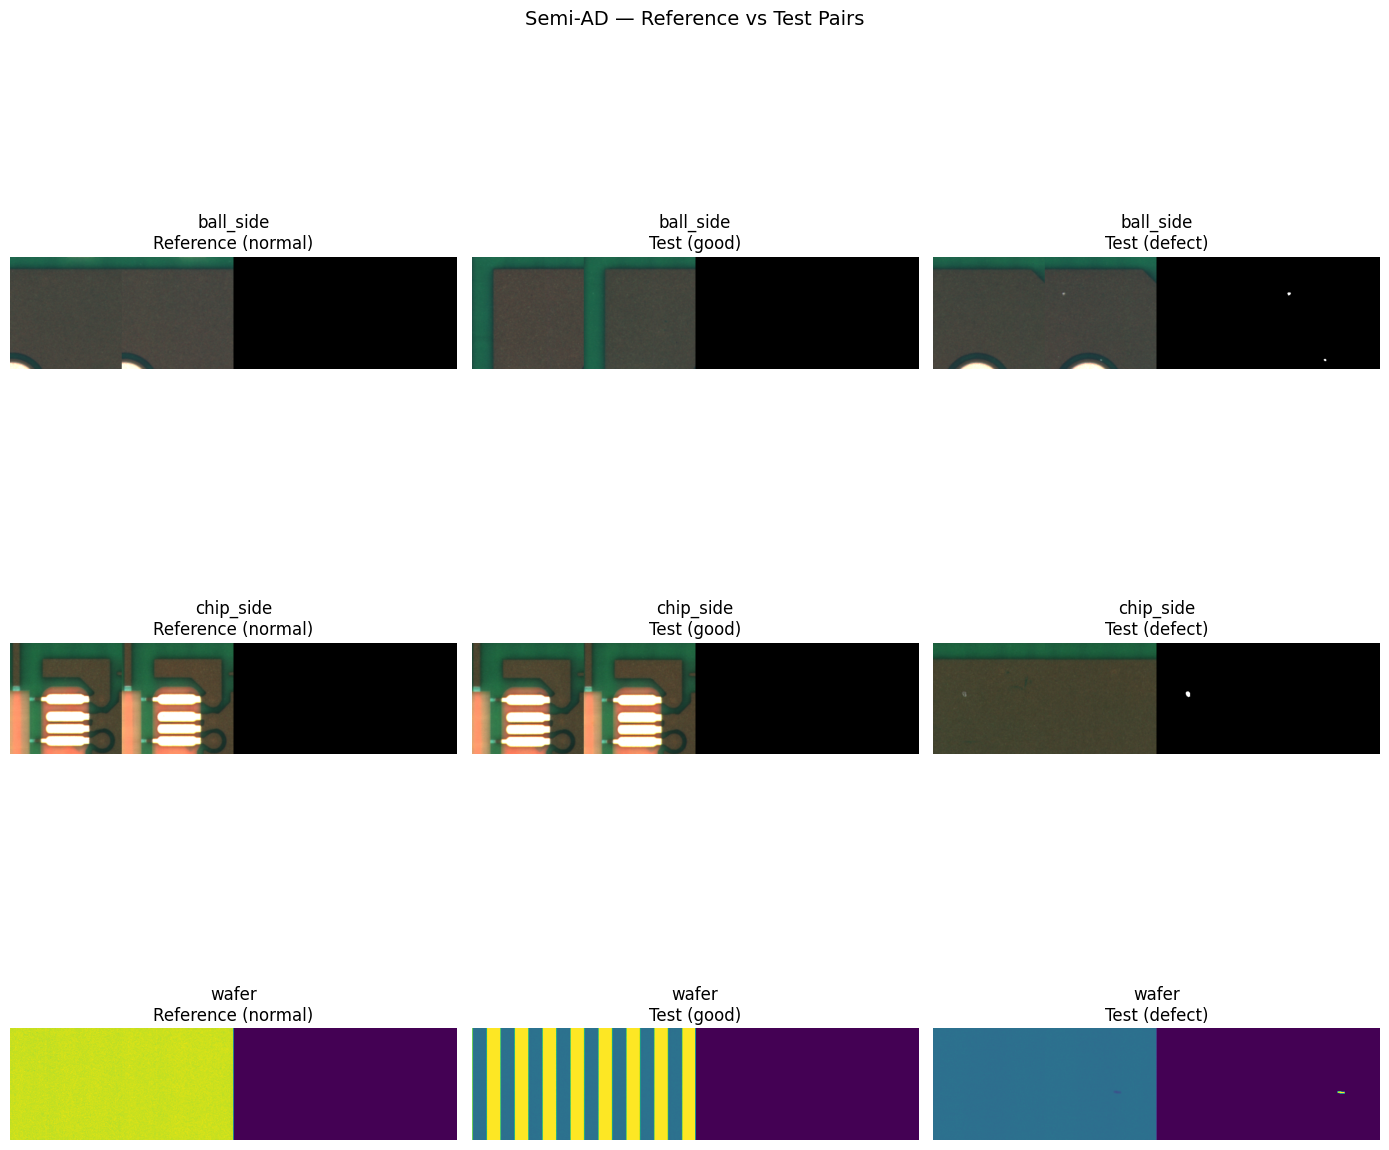

Saved.


In [5]:
def get_pair_images(base, category='good', idx=0):
    path = f'{base}/pair_set/test/{category}'
    imgs = sorted([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return Image.open(f'{path}/{imgs[idx]}'), imgs[idx]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for row, name in enumerate(subsets_list):
    base = SUBSETS[name]

    # Reference (normal train)
    train_path = f'{base}/pair_set/train/good'
    train_imgs = sorted(os.listdir(train_path))
    ref_img = Image.open(f'{train_path}/{train_imgs[0]}')
    axes[row, 0].imshow(ref_img)
    axes[row, 0].set_title(f'{name}\nReference (normal)')
    axes[row, 0].axis('off')

    # Test good
    good_img, _ = get_pair_images(base, 'good', 0)
    axes[row, 1].imshow(good_img)
    axes[row, 1].set_title(f'{name}\nTest (good)')
    axes[row, 1].axis('off')

    # Test defect
    defect_img, _ = get_pair_images(base, 'defect', 0)
    axes[row, 2].imshow(defect_img)
    axes[row, 2].set_title(f'{name}\nTest (defect)')
    axes[row, 2].axis('off')

plt.suptitle('Semi-AD — Reference vs Test Pairs', fontsize=14)
plt.tight_layout()
plt.savefig(f'{reports_path}/eda_pairs.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

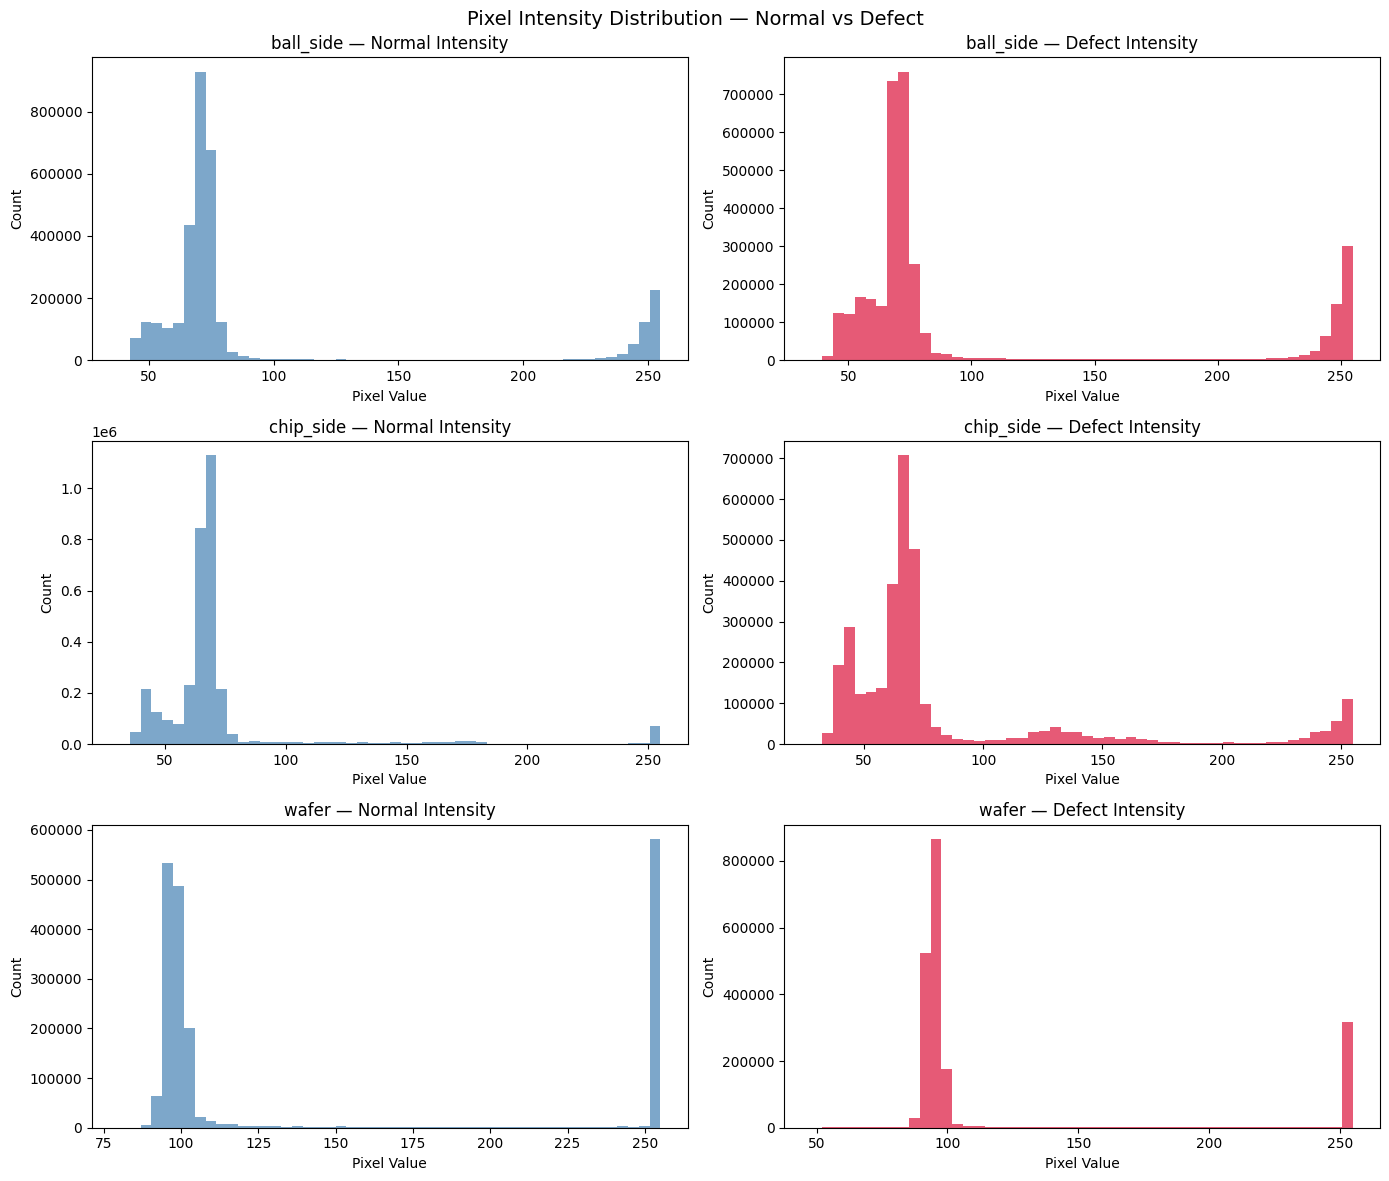

Saved.


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, name in enumerate(subsets_list):
    base = SUBSETS[name]
    
    # Load sample normal images
    normal_path = f'{base}/single_set/train/good'
    normal_imgs = sorted(os.listdir(normal_path))[:50]
    normal_pixels = []
    for img_name in normal_imgs:
        img = np.array(Image.open(f'{normal_path}/{img_name}').convert('L'))
        normal_pixels.extend(img.flatten())
    
    # Load sample defective images
    defect_path = f'{base}/single_set/test/defect'
    defect_imgs = sorted(os.listdir(defect_path))[:50]
    defect_pixels = []
    for img_name in defect_imgs:
        img = np.array(Image.open(f'{defect_path}/{img_name}').convert('L'))
        defect_pixels.extend(img.flatten())
    
    # Plot
    axes[row, 0].hist(normal_pixels, bins=50, color='steelblue', alpha=0.7)
    axes[row, 0].set_title(f'{name} — Normal Intensity')
    axes[row, 0].set_xlabel('Pixel Value')
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(defect_pixels, bins=50, color='crimson', alpha=0.7)
    axes[row, 1].set_title(f'{name} — Defect Intensity')
    axes[row, 1].set_xlabel('Pixel Value')
    axes[row, 1].set_ylabel('Count')

plt.suptitle('Pixel Intensity Distribution — Normal vs Defect', fontsize=14)
plt.tight_layout()
plt.savefig(f'{reports_path}/eda_intensity.png', bbox_inches='tight', dpi=150)
plt.show()

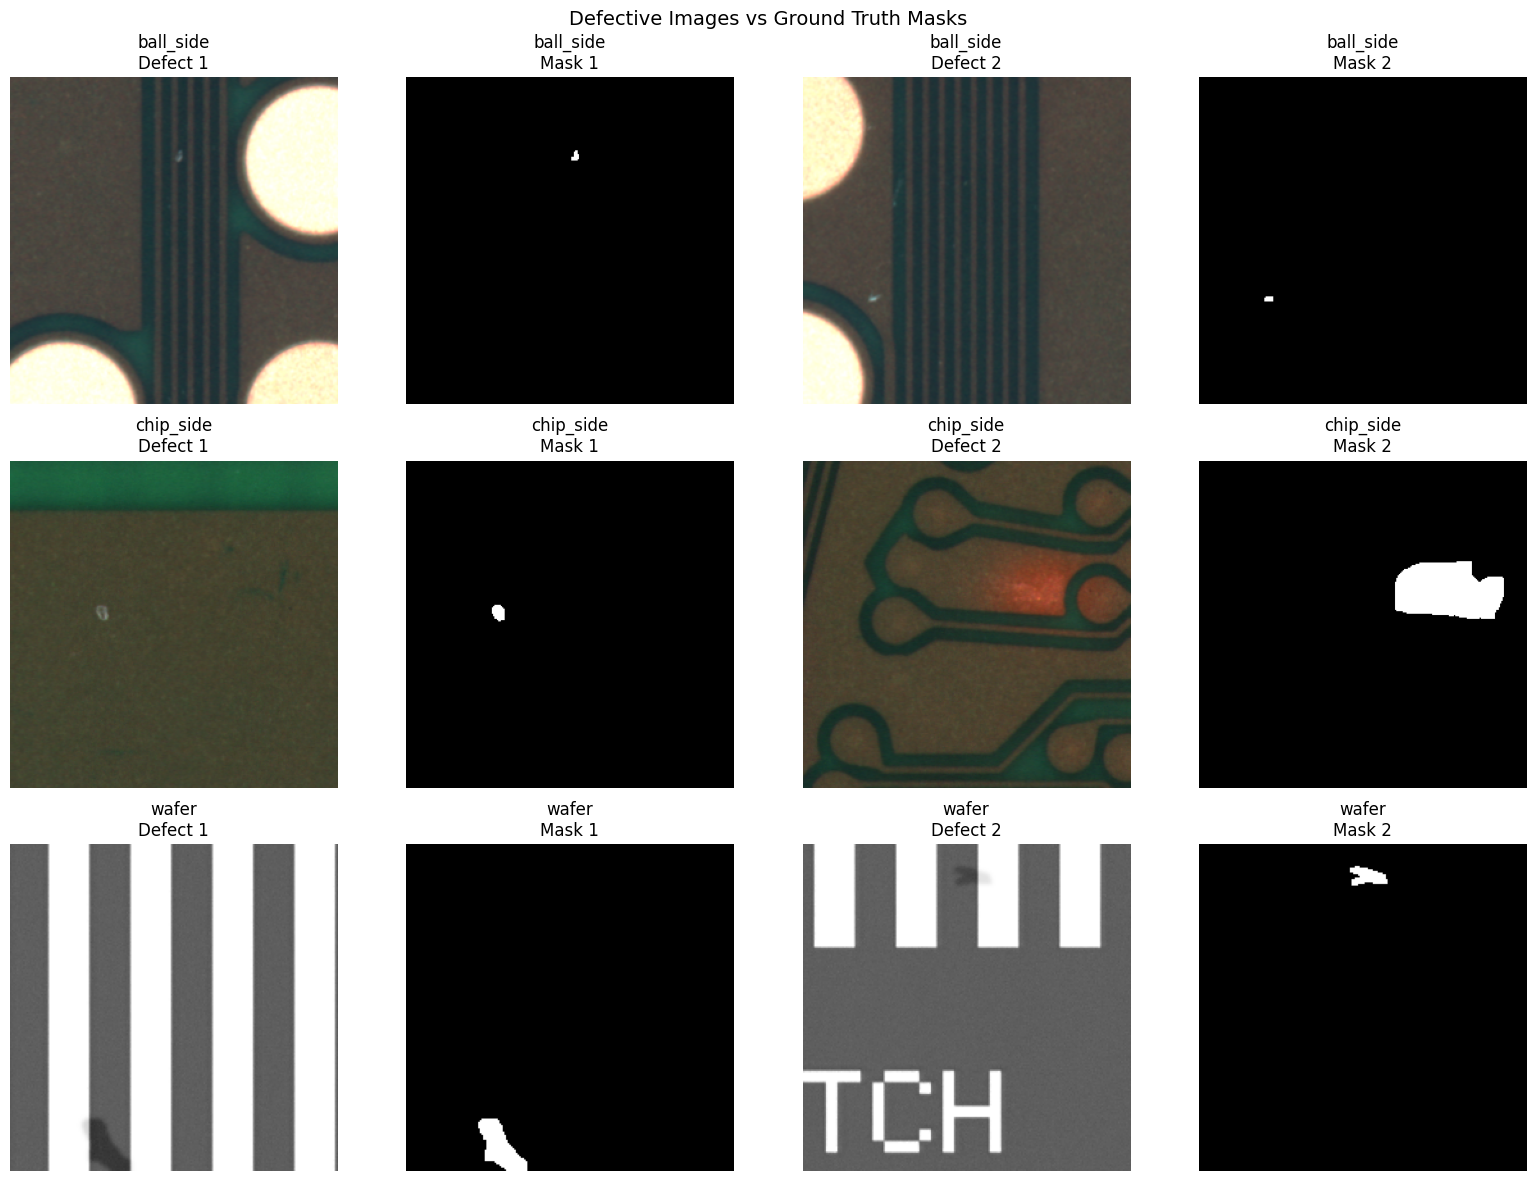

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, name in enumerate(subsets_list):
    base = SUBSETS[name]
    
    defect_path = f'{base}/single_set/test/defect'
    gt_path = f'{base}/single_set/ground_truth/defect'
    
    defect_imgs = sorted(os.listdir(defect_path))
    gt_imgs = sorted(os.listdir(gt_path))
    
    for col, idx in enumerate([0, 1]):
        # Defective image
        defect_img = Image.open(f'{defect_path}/{defect_imgs[idx]}')
        axes[row, col*2].imshow(defect_img)
        axes[row, col*2].set_title(f'{name}\nDefect {idx+1}')
        axes[row, col*2].axis('off')
        
        # Ground truth mask
        gt_img = Image.open(f'{gt_path}/{gt_imgs[idx]}')
        axes[row, col*2+1].imshow(gt_img, cmap='hot')
        axes[row, col*2+1].set_title(f'{name}\nMask {idx+1}')
        axes[row, col*2+1].axis('off')

plt.suptitle('Defective Images vs Ground Truth Masks', fontsize=14)
plt.tight_layout()
plt.savefig(f'{reports_path}/eda_masks.png', bbox_inches='tight', dpi=150)
plt.show()

In [9]:
print("=" * 50)
print(f"{'Subset':<12} {'Mean Defect %':>15} {'Min %':>8} {'Max %':>8}")
print("=" * 50)

for name in subsets_list:
    base = SUBSETS[name]
    gt_path = f'{base}/single_set/ground_truth/defect'
    gt_imgs = sorted(os.listdir(gt_path))
    
    defect_ratios = []
    for gt_name in gt_imgs:
        mask = np.array(Image.open(f'{gt_path}/{gt_name}').convert('L'))
        defect_ratio = (mask > 0).sum() / mask.size * 100
        defect_ratios.append(defect_ratio)
    
    print(f"{name:<12} {np.mean(defect_ratios):>14.2f}% {np.min(defect_ratios):>7.2f}% {np.max(defect_ratios):>7.2f}%")

print("=" * 50)

Subset         Mean Defect %    Min %    Max %
ball_side              0.15%    0.00%    2.34%
chip_side              0.34%    0.01%    4.71%
wafer                  1.15%    0.01%   13.31%


In [10]:
! pip install torch torchvision
! pip install scikit-learn tqdm

     |████████████████████████████████| 73.6 MB 766 kB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 2.9 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 5.3 MB/s eta 0:00:01
  Using cached networkx-3.2.1-py3-none-any.whl (1.6 MB)
     |████████████████████████████████| 200 kB 3.4 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 2.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/zabir/Documents/SemiAD/semiad_env/bin/python3 -m pip install --upgrade pip' command.
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
You should consider upgrading via the '/Users/zabir/Documents/SemiAD/semiad_env/bin/python3 -m pip install --upgrade pip' command.
